In [23]:
import os, json, math, random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from collections import defaultdict
import sys

sys.path.append("..")
from src.evaluation import temporal_train_test_split, evaluate_model
from src.text_features import TextFeatureExtractor
from src.image_features import CLIPFeatureExtractor

MODEL_NAME = "mmgcn_tmc"
RESULTS_DIR = f"../results/{MODEL_NAME}"

EMBED_DIM = 64
DIM_LATENT_V = 256
AGGR_MODE = "mean"
CONCATE = False
HAS_ID = True

EVIDENCE_DIM = 16
_KL = 0.1
ANNEALING_STEP = 10

# Entrenamiento
EPOCHS = 150
LR = 1e-4
WEIGHT_DECAY = 1e-5
BATCH_SIZE = 1024
LIKE_THRESHOLD = 4.0
EPS = 1e-8

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

Device: cuda


In [24]:
class BaseModel(nn.Module):
    """h = adj @ (x @ W), equivalente sin PyG a BaseModel."""

    def __init__(self, in_channels, out_channels, aggr="mean"):
        super().__init__()
        self.weight = nn.Parameter(torch.Tensor(in_channels, out_channels))
        bound = 1.0 / math.sqrt(in_channels)
        nn.init.uniform_(self.weight, -bound, bound)

    def forward(self, x, adj):
        return torch.sparse.mm(adj, x @ self.weight)


class GCN(nn.Module):
    """
    GCN con modalidad de 3 capas, preference learnable,
    id_embedding residual, F.normalize, LeakyReLU.
    """

    def __init__(
        self, num_user, num_item, dim_feat, dim_id, aggr_mode, concate, has_id, dim_latent=None
    ):
        super().__init__()
        self.dim_latent = dim_latent
        self.concate = concate
        self.has_id = has_id
        dim0 = dim_latent if dim_latent else dim_feat

        if dim_latent:
            self.preference = nn.Parameter(nn.init.xavier_normal_(torch.rand(num_user, dim_latent)))
            self.MLP = nn.Linear(dim_feat, dim_latent)
        else:
            self.preference = nn.Parameter(nn.init.xavier_normal_(torch.rand(num_user, dim_feat)))

        self.conv_embed_1 = BaseModel(dim0, dim0, aggr=aggr_mode)
        nn.init.xavier_normal_(self.conv_embed_1.weight)
        self.linear_layer1 = nn.Linear(dim0, dim_id)
        nn.init.xavier_normal_(self.linear_layer1.weight)
        self.g_layer1 = nn.Linear(dim0 + dim_id if concate else dim0, dim_id)
        nn.init.xavier_normal_(self.g_layer1.weight)

        self.conv_embed_2 = BaseModel(dim_id, dim_id, aggr=aggr_mode)
        nn.init.xavier_normal_(self.conv_embed_2.weight)
        self.linear_layer2 = nn.Linear(dim_id, dim_id)
        nn.init.xavier_normal_(self.linear_layer2.weight)
        self.g_layer2 = nn.Linear(dim_id * 2 if concate else dim_id, dim_id)
        nn.init.xavier_normal_(self.g_layer2.weight)

        self.conv_embed_3 = BaseModel(dim_id, dim_id, aggr=aggr_mode)
        nn.init.xavier_normal_(self.conv_embed_3.weight)
        self.linear_layer3 = nn.Linear(dim_id, dim_id)
        nn.init.xavier_normal_(self.linear_layer3.weight)
        self.g_layer3 = nn.Linear(dim_id * 2 if concate else dim_id, dim_id)
        nn.init.xavier_normal_(self.g_layer3.weight)

    def _layer(self, conv, linear, g, x, id_emb, adj):
        h = F.leaky_relu(conv(x, adj))
        x_hat = F.leaky_relu(linear(x))
        if self.has_id:
            x_hat = x_hat + id_emb
        if self.concate:
            return F.leaky_relu(g(torch.cat([h, x_hat], dim=1)))
        return F.leaky_relu(g(h) + x_hat)

    def forward(self, features, id_embedding, adj):
        temp = self.MLP(features) if self.dim_latent else features
        x = F.normalize(torch.cat([self.preference, temp], dim=0))
        x = self._layer(self.conv_embed_1, self.linear_layer1, self.g_layer1, x, id_embedding, adj)
        x = self._layer(self.conv_embed_2, self.linear_layer2, self.g_layer2, x, id_embedding, adj)
        x = self._layer(self.conv_embed_3, self.linear_layer3, self.g_layer3, x, id_embedding, adj)
        return x

In [25]:
class DSFusionLayer(nn.Module):
    """
    Fusión multimodal con la regla de combinación reducida de Dempster-Shafer.
    Implementa las Ecuaciones 11, 13 y 15 del paper TMC
    (Han et al., IEEE TPAMI 45(2), 2023).
    """

    def __init__(self, input_dim: int, evidence_dim: int, output_dim: int):
        super().__init__()
        self.K = evidence_dim
        self.proj_img = nn.Linear(input_dim, evidence_dim)
        self.proj_text = nn.Linear(input_dim, evidence_dim)
        # Proyecta la evidencia combinada al espacio de embeddings para BPR
        self.out_proj = nn.Linear(evidence_dim, output_dim)

    def _to_masses(self, raw):
        """Proyección lineal - alpha, b, u."""
        alpha = F.softplus(raw) + 1.0
        S = alpha.sum(dim=-1, keepdim=True)
        b = (alpha - 1.0) / (S + EPS)
        u = self.K / (S + EPS)
        return alpha, b, u

    @staticmethod
    def _combine(b1, u1, b2, u2):
        """Regla de combinación reducida de Dempster."""
        C = b1.sum(dim=-1, keepdim=True) * b2.sum(dim=-1, keepdim=True) - (b1 * b2).sum(
            dim=-1, keepdim=True
        )
        C = C.clamp(min=0.0, max=1.0 - EPS)
        scale = 1.0 / (1.0 - C + EPS)
        b_out = scale * (b1 * b2 + b1 * u2 + b2 * u1)
        u_out = scale * u1 * u2
        return b_out, u_out

    def forward(self, e_img, e_txt):
        """
        Retorna:
          emb : [N, output_dim] embedding para BPR (en R^d, fuera del símplex)
          alpha_joint: [N, K] paráms Dirichlet conjunta   (para diagnóstico)
          alpha_img : [N, K] paráms Dirichlet imagen     (para KL)
          alpha_txt : [N, K] paráms Dirichlet texto      (para KL)
        """
        alpha_img, b_img, u_img = self._to_masses(self.proj_img(e_img))
        alpha_txt, b_txt, u_txt = self._to_masses(self.proj_text(e_txt))

        # Regla de Dempster (Ec. 13)
        b_joint, u_joint = self._combine(b_img, u_img, b_txt, u_txt)

        # Recuperar Dirichlet conjunta (Ec. 15)
        u_joint = u_joint.clamp(min=float(self.K) / 1e5)
        S_joint = self.K / (u_joint + EPS)
        alpha_joint = b_joint * S_joint + 1.0
        emb = self.out_proj(alpha_joint - 1.0)

        return emb, alpha_joint, alpha_img, alpha_txt

In [26]:
class Net(nn.Module):
    """
    MMGCN fiel al repo + fusión Dempster-Shafer (TMC).
    Loss: BPR + (lambda/K)·(KL_img + KL_txt) + L2 reg.
    """

    def __init__(
        self,
        img_feat,
        text_feat,
        edge_index,
        num_user,
        num_item,
        aggr_mode,
        concate,
        has_id,
        reg_weight,
        dim_x,
        evidence_dim,
        _kl,
        annealing_step,
        device,
    ):
        super().__init__()
        self.num_user = num_user
        self.num_item = num_item
        self.reg_weight = reg_weight
        self._kl = _kl
        self.annealing_step = annealing_step
        self.device = device

        # Adyacencia bidireccional normalizada (igual que nb14)
        N = num_user + num_item
        ei = np.array(edge_index)
        rows = np.concatenate([ei[:, 0], ei[:, 1]])
        cols = np.concatenate([ei[:, 1], ei[:, 0]])
        deg = np.bincount(rows, minlength=N).astype(float)
        if aggr_mode == "mean":
            vals = np.where(deg[rows] > 0, 1.0 / deg[rows], 0.0)
        else:
            vals = np.ones(len(rows), dtype=np.float32)
        idx = torch.LongTensor(np.stack([rows, cols]))
        v = torch.FloatTensor(vals)
        self.register_buffer("adj", torch.sparse_coo_tensor(idx, v, (N, N)).coalesce())
        self.register_buffer("img_feat", img_feat.float())
        self.register_buffer("text_feat", text_feat.float())

        # Un GCN por modalidad (igual que nb14)
        self.img_gcn = GCN(
            num_user,
            num_item,
            img_feat.shape[1],
            dim_x,
            aggr_mode,
            concate,
            has_id,
            dim_latent=DIM_LATENT_V,
        )
        self.text_gcn = GCN(
            num_user,
            num_item,
            text_feat.shape[1],
            dim_x,
            aggr_mode,
            concate,
            has_id,
            dim_latent=None,
        )
        self.id_embedding = nn.Parameter(
            nn.init.xavier_normal_(torch.rand(num_user + num_item, dim_x))
        )

        # Fusión DS-TMC: opera en evidence_dim (pequeño), proyecta a dim_x para BPR
        self.fusion = DSFusionLayer(dim_x, evidence_dim, output_dim=dim_x)

    def _encode(self):
        """Propaga ambas GCNs - (e_img, e_txt) de shape [N, dim_x]."""
        e_img = self.img_gcn(self.img_feat, self.id_embedding, self.adj)
        e_txt = self.text_gcn(self.text_feat, self.id_embedding, self.adj)
        return e_img, e_txt

    @staticmethod
    def _kl_dirichlet_uniform(alpha):
        """
        KL[Dir(alpha) || Dir(1,...,1)]
        """
        K = alpha.shape[-1]
        S = alpha.sum(dim=-1, keepdim=True)
        K_t = torch.tensor(float(K), device=alpha.device, dtype=alpha.dtype)
        log_ratio = (
            torch.lgamma(S) - torch.lgamma(K_t) - torch.lgamma(alpha).sum(dim=-1, keepdim=True)
        )
        cross = ((alpha - 1.0) * (torch.digamma(alpha) - torch.digamma(S))).sum(
            dim=-1, keepdim=True
        )
        return (log_ratio + cross).squeeze(-1).clamp(min=0.0)

    def forward(self):
        """Para recomendación: emb [N, dim_x] en R^d (fuera del símplex)."""
        e_img, e_txt = self._encode()
        emb, _, _, _ = self.fusion(e_img, e_txt)
        return emb

    def loss(self, user_tensor, item_tensor, epoch):
        """
        L = BPR(emb_combined) + (lambda/K)·(KL_img + KL_txt) + L2_reg

        Correspondencia con TMC
          BPR  L_fused  (pérdida en la salida combinada)
          (lambda/K)·KL_m  término KL de cada L_m (normalizado por dimensión)
        """
        user_tensor = user_tensor.view(-1)  # [2B]
        item_tensor = item_tensor.view(-1)  # [2B]

        e_img, e_txt = self._encode()  # [N, dim_x]

        # Embeddings del mini-batch
        u_img = e_img[user_tensor]
        u_txt = e_txt[user_tensor]
        i_img = e_img[item_tensor]
        i_txt = e_txt[item_tensor]

        # Fusión DS para usuarios y pares (pos/neg) de ítems
        emb_u, _, a_img_u, a_txt_u = self.fusion(u_img, u_txt)
        emb_i, _, a_img_i, a_txt_i = self.fusion(i_img, i_txt)

        # BPR sobre emb (en R^dim_x, con varianza normal para aprender)
        dot = torch.sum(emb_u * emb_i, dim=1).view(-1, 2)
        bpr_loss = -F.logsigmoid(dot[:, 0] - dot[:, 1]).mean()

        # KL por modalidad (Ec. 8), escalado por 1/K para compensar alta dimensión
        kl_img = self._kl_dirichlet_uniform(torch.cat([a_img_u, a_img_i])).mean()
        kl_txt = self._kl_dirichlet_uniform(torch.cat([a_txt_u, a_txt_i])).mean()
        K = float(self.fusion.K)
        lam = self._kl * min(1.0, epoch / max(1, self.annealing_step))

        # L2 sobre id_embedding y preference (igual que nb14)
        reg_emb = (
            self.id_embedding[user_tensor] ** 2 + self.id_embedding[item_tensor] ** 2
        ).mean() + (self.img_gcn.preference**2).mean()

        total = bpr_loss + (lam / K) * (kl_img + kl_txt) + self.reg_weight * reg_emb
        return total, {
            "bpr": bpr_loss.detach(),
            "kl_img": kl_img.detach(),
            "kl_txt": kl_txt.detach(),
            "_eff": lam / K,
        }

In [27]:
class TrainingDataset(Dataset):
    """Cada sample: ([user, user], [pos_item, neg_item])."""

    def __init__(self, num_user, num_item, user_item_dict, pos_edges):
        self.pos_edges = pos_edges
        self.user_item_dict = user_item_dict
        self.all_items = list(range(num_user, num_user + num_item))

    def __len__(self):
        return len(self.pos_edges)

    def __getitem__(self, index):
        user, pos_item = self.pos_edges[index]
        seen = self.user_item_dict.get(user, set())
        neg_item = random.choice(self.all_items)
        while neg_item in seen:
            neg_item = random.choice(self.all_items)
        return torch.LongTensor([user, user]), torch.LongTensor([pos_item, neg_item])

In [28]:
class MMGCN_TMC:
    """MMGCN  con fusión Dempster-Shafer del paper TMC."""

    def __init__(self, text_embeddings, image_embeddings, embed_dim=64, device="cpu"):
        common = sorted(set(text_embeddings) & set(image_embeddings))
        self._item_ids = common
        self._item_idx = {b: i for i, b in enumerate(common)}
        self.num_item = len(common)

        self._img_feat = torch.FloatTensor(np.stack([image_embeddings[b] for b in common]))
        self._text_feat = torch.FloatTensor(np.stack([text_embeddings[b] for b in common]))

        self._embed_dim = embed_dim
        self.device = device
        self._net = None
        self._user_idx = None
        self.num_user = None
        self._emb_cache = None

        print(
            f"MMGCN_TMC: {self.num_item:,} items | "
            f"image={self._img_feat.shape[1]}d | text={self._text_feat.shape[1]}d"
        )

    def _build_structures(self, train_reviews):
        filtered = train_reviews[train_reviews["business_id"].isin(self._item_idx)].copy()

        all_users = filtered["user_id"].unique()
        self._user_idx = {u: i for i, u in enumerate(all_users)}
        self.num_user = len(all_users)

        u_nodes = filtered["user_id"].map(self._user_idx).values
        i_nodes = filtered["business_id"].map(self._item_idx).values + self.num_user
        all_edges = list(zip(u_nodes.tolist(), i_nodes.tolist()))

        user_item_dict = defaultdict(set)
        for u, i in all_edges:
            user_item_dict[u].add(i)

        liked = filtered[filtered["stars"] >= LIKE_THRESHOLD]
        lu = liked["user_id"].map(self._user_idx).values
        li = liked["business_id"].map(self._item_idx).values + self.num_user
        liked_edges = list(zip(lu.tolist(), li.tolist())) or all_edges

        print(
            f"  Usuarios: {self.num_user:,} | "
            f"Aristas grafo: {len(all_edges):,} | "
            f"Positivos (≥{LIKE_THRESHOLD}★): {len(liked_edges):,}"
        )
        return all_edges, dict(user_item_dict), liked_edges

    def fit(
        self,
        train_reviews,
        epochs=EPOCHS,
        lr=LR,
        weight_decay=WEIGHT_DECAY,
        batch_size=BATCH_SIZE,
        evidence_dim=EVIDENCE_DIM,
        _kl=_KL,
        annealing_step=ANNEALING_STEP,
    ):
        torch.manual_seed(42)
        random.seed(42)
        self._emb_cache = None

        all_edges, user_item_dict, liked_edges = self._build_structures(train_reviews)

        self._net = Net(
            self._img_feat,
            self._text_feat,
            all_edges,
            self.num_user,
            self.num_item,
            aggr_mode=AGGR_MODE,
            concate=CONCATE,
            has_id=HAS_ID,
            reg_weight=weight_decay,
            dim_x=self._embed_dim,
            evidence_dim=evidence_dim,
            _kl=_kl,
            annealing_step=annealing_step,
            device=self.device,
        ).to(self.device)

        dataset = TrainingDataset(self.num_user, self.num_item, user_item_dict, liked_edges)
        loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=0)
        optimizer = torch.optim.Adam(self._net.parameters(), lr=lr)

        print(
            f"BPR+DS-KL | K={evidence_dim} | {len(dataset):,} positivos | "
            f"{epochs} epochs | bs={batch_size}"
        )

        for epoch in range(1, epochs + 1):
            self._net.train()
            s_total = s_bpr = s_ki = s_kt = steps = 0
            for u_t, i_t in loader:
                u_t, i_t = u_t.to(self.device), i_t.to(self.device)
                optimizer.zero_grad()
                total, ldict = self._net.loss(u_t, i_t, epoch)
                total.backward()
                optimizer.step()
                s_total += total.item()
                s_bpr += ldict["bpr"].item()
                s_ki += ldict["kl_img"].item()
                s_kt += ldict["kl_txt"].item()
                steps += 1
            if epoch % 10 == 0:
                leff = ldict["_eff"]
                print(
                    f"  Epoch {epoch:3d}/{epochs} | "
                    f"loss: {s_total/steps:.4f} | bpr: {s_bpr/steps:.4f} | "
                    f"KL_img: {s_ki/steps:.4f} | KL_txt: {s_kt/steps:.4f} | "
                    f"lambda_eff={leff:.4f}"
                )

        self._net.eval()
        return self

    def recommend(self, user_id, train_reviews, top_k=10):
        if self._net is None or user_id not in self._user_idx:
            return []
        seen = set(train_reviews[train_reviews["user_id"] == user_id]["business_id"])
        cands = [b for b in self._item_ids if b not in seen]
        if not cands:
            return []

        if self._emb_cache is None:
            with torch.no_grad():
                self._emb_cache = self._net.forward().detach()

        u_node = self._user_idx[user_id]
        c_nodes = [self.num_user + self._item_idx[b] for b in cands]
        u_f = self._emb_cache[u_node].unsqueeze(0)
        c_f = self._emb_cache[c_nodes]
        scores = (u_f * c_f).sum(-1).cpu().numpy()

        top = np.argsort(scores)[::-1][:top_k]
        return [cands[i] for i in top]

## Datos y embeddings

In [29]:
reviews = pd.read_csv("../data/processed/reviews.csv", parse_dates=["date"])
train_reviews, test_reviews = temporal_train_test_split(reviews, test_fraction=0.2)

text_embeddings = TextFeatureExtractor.load("text_embeddings.npz")
image_embeddings = CLIPFeatureExtractor.load("clip_embeddings.npz")

print(f"Text: {len(text_embeddings):,} | Image (CLIP): {len(image_embeddings):,}")
print(f"Overlap: {len(set(text_embeddings) & set(image_embeddings)):,} items con ambas modalidades")

Train: 61870 reviews | Test: 13114 reviews
Text: 1,151 | Image (CLIP): 3,824
Overlap: 1,151 items con ambas modalidades


## Entrenar MMGCN + DS-TMC

In [30]:
model = MMGCN_TMC(
    text_embeddings,
    image_embeddings,
    embed_dim=EMBED_DIM,
    device=DEVICE,
)
model.fit(
    train_reviews,
    epochs=EPOCHS,
    lr=LR,
    weight_decay=WEIGHT_DECAY,
    batch_size=BATCH_SIZE,
    evidence_dim=EVIDENCE_DIM,
    _kl=_KL,
    annealing_step=ANNEALING_STEP,
)

MMGCN_TMC: 1,151 items | image=512d | text=384d
  Usuarios: 6,503 | Aristas grafo: 44,176 | Positivos (≥4.0★): 32,831
BPR+DS-KL | K=16 | 32,831 positivos | 150 epochs | bs=1024
  Epoch  10/150 | loss: 0.1556 | bpr: 0.1405 | KL_img: 1.2863 | KL_txt: 1.1254 | lambda_eff=0.0063
  Epoch  20/150 | loss: 0.1579 | bpr: 0.1435 | KL_img: 1.2052 | KL_txt: 1.0859 | lambda_eff=0.0063
  Epoch  30/150 | loss: 0.1534 | bpr: 0.1400 | KL_img: 1.1091 | KL_txt: 1.0395 | lambda_eff=0.0063
  Epoch  40/150 | loss: 0.1524 | bpr: 0.1400 | KL_img: 0.9970 | KL_txt: 0.9772 | lambda_eff=0.0063
  Epoch  50/150 | loss: 0.1284 | bpr: 0.1168 | KL_img: 0.9491 | KL_txt: 0.9027 | lambda_eff=0.0063
  Epoch  60/150 | loss: 0.1268 | bpr: 0.1166 | KL_img: 0.8099 | KL_txt: 0.8122 | lambda_eff=0.0063
  Epoch  70/150 | loss: 0.1194 | bpr: 0.1105 | KL_img: 0.7200 | KL_txt: 0.7114 | lambda_eff=0.0063
  Epoch  80/150 | loss: 0.1129 | bpr: 0.1051 | KL_img: 0.6318 | KL_txt: 0.6101 | lambda_eff=0.0063
  Epoch  90/150 | loss: 0.1135 

## Evaluación

In [31]:
# ILD necesita un espacio de features comun a todos los modelos (SBERT)
from src.text_features import TextFeatureExtractor
if 'text_embeddings' not in globals():
    text_embeddings = TextFeatureExtractor.load('text_embeddings.npz')

metrics = evaluate_model(
    lambda uid, top_k: model.recommend(uid, train_reviews, top_k),
    test_reviews,
    train_reviews,
    k_values=[5, 10, 20],
    item_features=text_embeddings,
)
print("MMGCN_v2 + DS-TMC metrics:")
print(metrics.round(4))

MMGCN_v2 + DS-TMC metrics:
    precision  recall    ndcg  novelty  hit_rate  coverage     ild
K                                                                 
5      0.0207  0.0586  0.0444   3.8635    0.0978    0.1168  0.5048
10     0.0168  0.0924  0.0558   4.0999    0.1532    0.1821  0.5067
20     0.0134  0.1427  0.0704   4.3473    0.2299    0.2887  0.5217


## Guardar resultados

In [32]:
os.makedirs(RESULTS_DIR, exist_ok=True)
metrics.to_csv(f"{RESULTS_DIR}/metrics.csv")
with open(f"{RESULTS_DIR}/config.json", "w") as f:
    json.dump(
        {
            "model": "MMGCN_TMC",
            "embed_dim": EMBED_DIM,
            "dim_latent_v": DIM_LATENT_V,
            "evidence_dim": EVIDENCE_DIM,
            "aggr_mode": AGGR_MODE,
            "concate": CONCATE,
            "has_id": HAS_ID,
            "epochs": EPOCHS,
            "lr": LR,
            "weight_decay": WEIGHT_DECAY,
            "_kl": _KL,
            "annealing_step": ANNEALING_STEP,
            "batch_size": BATCH_SIZE,
            "like_threshold": LIKE_THRESHOLD,
            "image_model": "CLIP (512d)",
            "text_model": "all-MiniLM-L6-v2",
            "loss": "BPR + KL-DS + L2 reg",
            "fusion": "Dempster-Shafer (TMC, Han et al. TPAMI 2023)",
            "fusion_ref": "DOI: 10.1109/TPAMI.2022.3171983",
            "gcn_layers": 3,
            "n_items_multimodal": model.num_item,
            "n_users": model.num_user,
        },
        f,
        indent=2,
    )
print(f"Saved -> results/{MODEL_NAME}/")

Saved -> results/mmgcn_tmc/


## Ejemplos de recomendaciones

5 usuarios fijos (seed=42, los mismos en todos los notebooks): historial + recomendaciones con texto, restaurante e imagen.

Usuarios de ejemplo: ['lo9Z0oVT-kz2DJwPE3X0Og', 'R53y0qIWqJZxnbyWNDbrMg', 'dzAZWHtJ52JI8J4zB2mkow', '4tqv48yYK6Jk5aZsncDC-g', 'QlueMJlhDGDGxR9arq_xSg']

Usuario lo9Z0oVT-kz2DJwPE3X0Og  |  5 reviews en train
------------------------------------------------------------------------
Historial (top 3 por rating):
  [5*] City Diner - "Finally a new diner in the city MUCH NEEDED for industry people & socialites that have late night schedules . Very Clean and mangled very well"
  [5*] National Mechanics - "Place is great but the evening server Jennifer makes it amazing. Most personable & welcoming server I've ever met. Make sure you guys keep her around P.S. the l..."
  [4*] Fare - "Good food pretty good variety menu . My favorite thing about this place is their outdoor courtyard which is very nice at night w/ the heated lamps & fireplace i..."
------------------------------------------------------------------------
Top 5 recomendaciones:
  1. Zahav (Philadelphia) - 4.5* - Nightlife, Bars, Foo

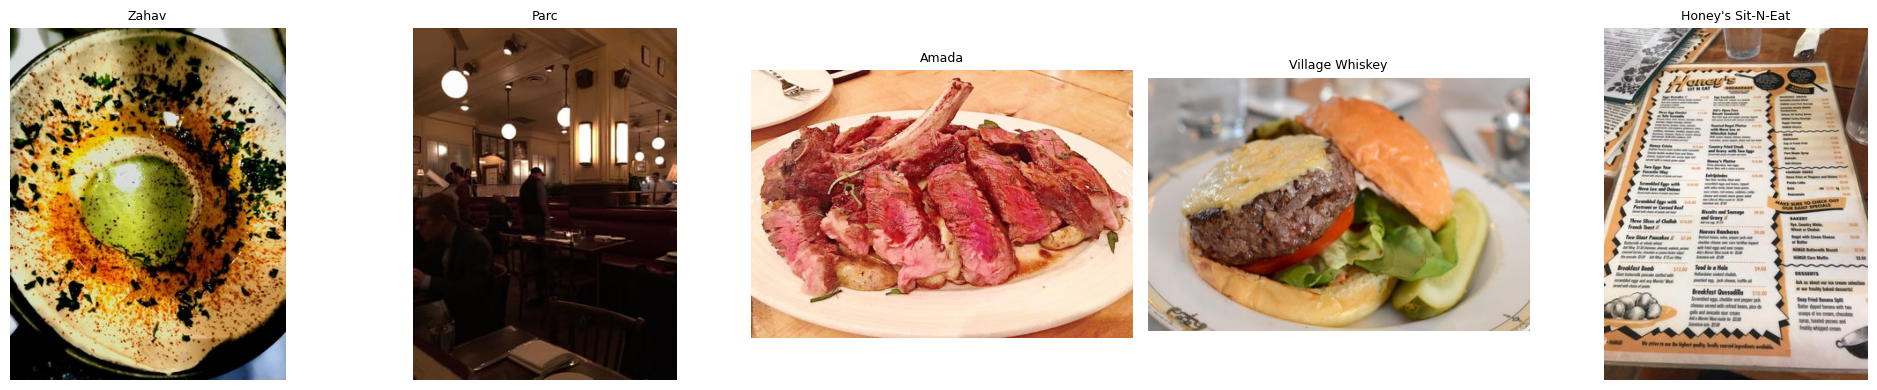


Usuario R53y0qIWqJZxnbyWNDbrMg  |  9 reviews en train
------------------------------------------------------------------------
Historial (top 3 por rating):
  [5*] Han Dynasty - "First, I must rave about the superb service we received by our waitress. We came here last Sunday after making reservations for 15 for my boyfriend's surprise b..."
  [4*] Crazy Sushi - "One item is enough to make me write this review:  Salmon Pizza! Get it! Pictures & a more thorough review to come when I return - which shall be soon."
  [4*] Moshulu - "This review is for their restaurant week menu  Food: 3.5/5  Apps: california shrimp crunch roll & crispy calamari/artichoke hearts Their appetizers were amazing..."
------------------------------------------------------------------------
Top 5 recomendaciones:
  1. Zahav (Philadelphia) - 4.5* - Nightlife, Bars, Food, Ethnic Food, Middle Eastern, Vegetari...
  2. Parc (Philadelphia) - 4.0* - Restaurants, French, Wine Bars, Nightlife, American (New), B...
  3. 

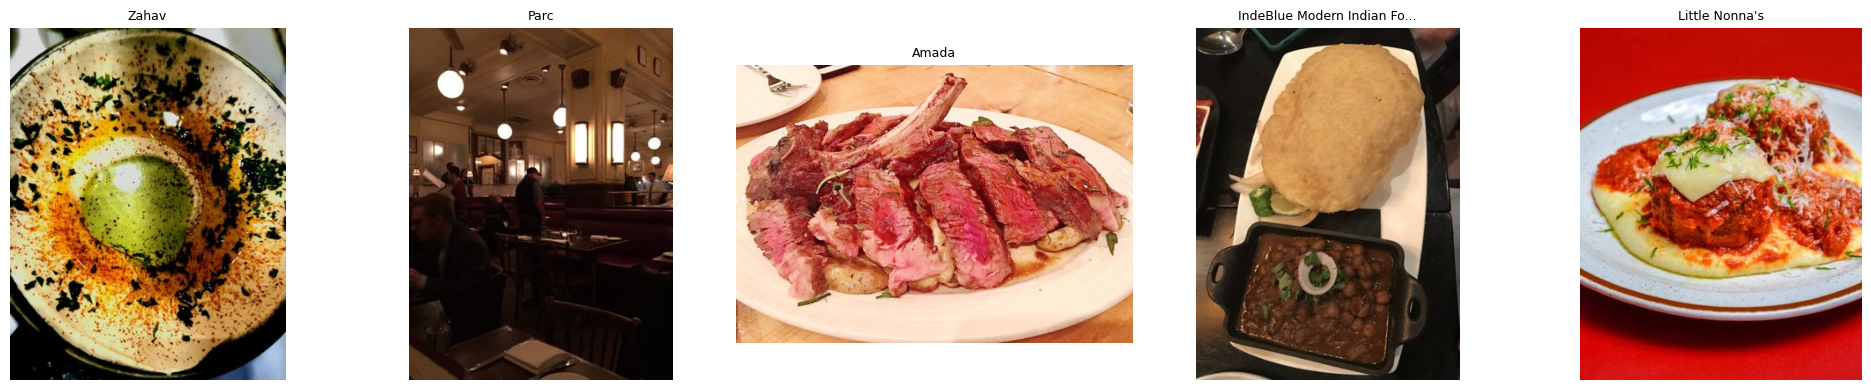


Usuario dzAZWHtJ52JI8J4zB2mkow  |  5 reviews en train
------------------------------------------------------------------------
Historial (top 3 por rating):
  [5*] Dalessandro’s Steaks & Hoagies - "And down simply the best cheesesteak in Philadelphia and make sure you go a little early because it's always packed door-to-door for lunch"
  [3*] Jim's South St - "Very tasty but they need to add more meat for 9$ cheesesteak  Their are a few better out there Delsandros and sonnys right up the street  Fries are not availabl..."
  [1*] John's Roast Pork - "Simply the most OVER RATED pork sandwich I've ever had...  Their cheese steaks are the highlight of this place!!!! Their prices are about par for the course"
------------------------------------------------------------------------
Top 5 recomendaciones:
  1. Zahav (Philadelphia) - 4.5* - Nightlife, Bars, Food, Ethnic Food, Middle Eastern, Vegetari...
  2. Village Whiskey (Philadelphia) - 4.0* - Bars, Nightlife, Whiskey Bars, Burgers, Resta

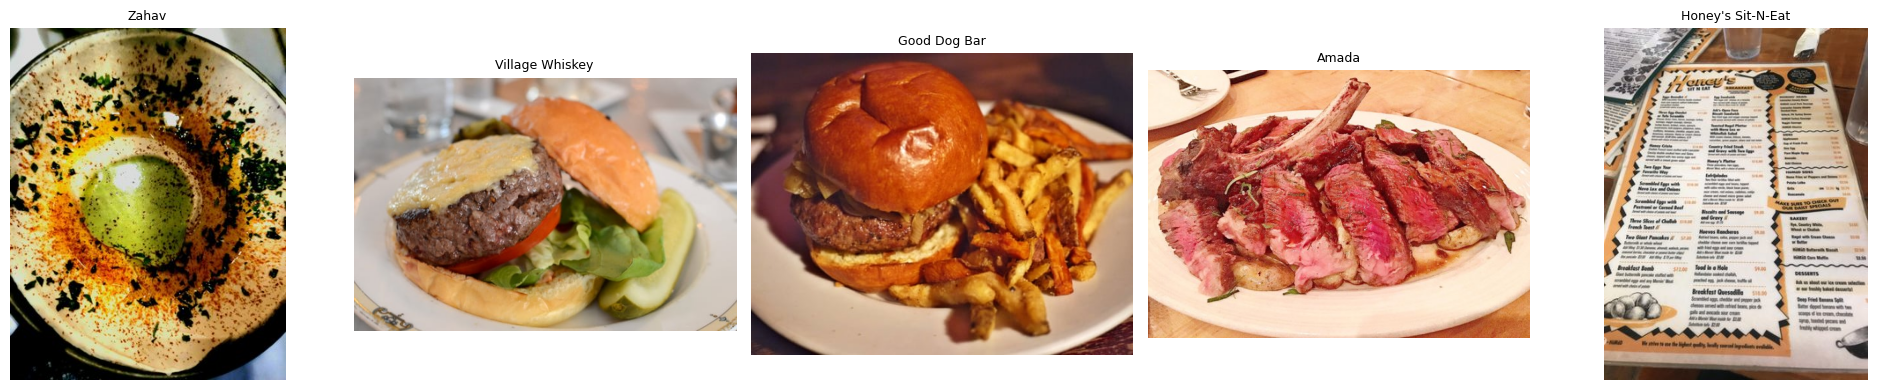


Usuario 4tqv48yYK6Jk5aZsncDC-g  |  20 reviews en train
------------------------------------------------------------------------
Historial (top 3 por rating):
  [5*] Tinto - "This place is one of those that you might not want to miss it if you live in Philadelphia. I went there last November and had an amazing time. The atmosphere in..."
  [5*] P S & Co - "Thumbs up to the owner for her brilliant ideas. Pure Sweet is a place that I truly feel I'm not waisting my money. I pursue a very restricted diet and the fact ..."
  [5*] The Farm and Fisherman - "What can I say about this place? It's a gem. I had dinner here couple of months ago leaving me with the best impressions. Service is outstanding. The server pre..."
------------------------------------------------------------------------
Top 5 recomendaciones:
  1. Zahav (Philadelphia) - 4.5* - Nightlife, Bars, Food, Ethnic Food, Middle Eastern, Vegetari...
  2. Parc (Philadelphia) - 4.0* - Restaurants, French, Wine Bars, Nightlife, Americ

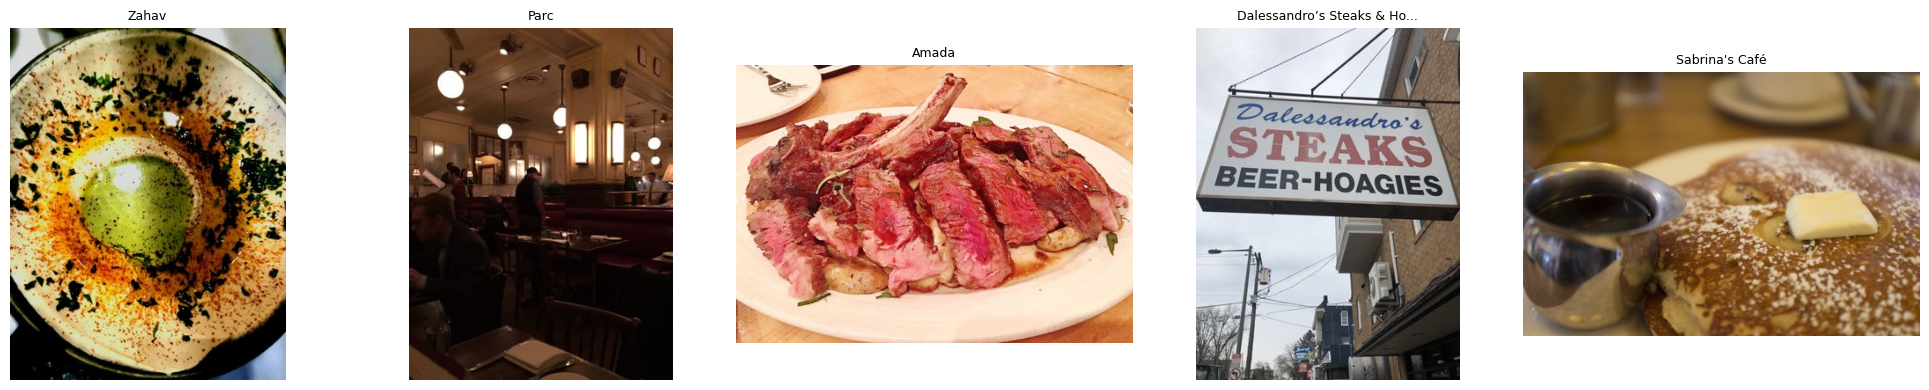


Usuario QlueMJlhDGDGxR9arq_xSg  |  4 reviews en train
------------------------------------------------------------------------
Historial (top 3 por rating):
  [5*] Pizzeria Vetri - "The arugula salad with pesto was hands down the best salad I've had in my life. And if you're even considering the Nutella dessert pie, get it. You won't be dis..."
  [5*] Dante & Luigi's - "Dante & Luigi's was the perfect place for my boyfriend and I to take his mom when she visited town. The atmosphere was great - felt just like you were in someon..."
  [5*] Kanella South - "The portions are large, the food is authentic, the new location is gorgeous, and the whole experience is amazing. I absolutely adore Kenella's!"
------------------------------------------------------------------------
Top 5 recomendaciones:
  1. Zahav (Philadelphia) - 4.5* - Nightlife, Bars, Food, Ethnic Food, Middle Eastern, Vegetari...
  2. Terakawa Ramen (Philadelphia) - 4.5* - Japanese, Ramen, Ethnic Food, Restaurants, Local Flav

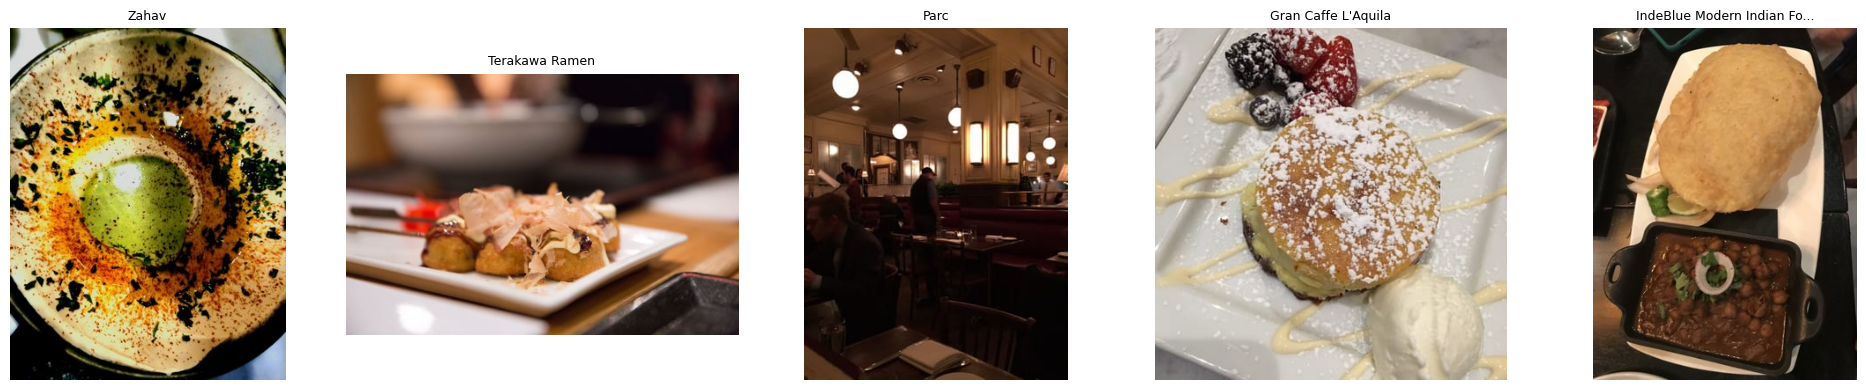

In [33]:
# 5 usuarios fijos por seed (mismos en todos los notebooks)
import pandas as pd
from src.examples import pick_sample_users, show_user_recommendations

restaurants_meta = pd.read_csv('../data/processed/restaurants.csv')
try:
    photos_meta = pd.read_csv('../data/processed/photos.csv')
except FileNotFoundError:
    photos_meta = None

sample_users = pick_sample_users(train_reviews, n=5, seed=42)
print('Usuarios de ejemplo:', sample_users)

for uid in sample_users:
    show_user_recommendations(
        uid,
        lambda u, top_k: model.recommend(u, train_reviews, top_k),
        train_reviews, restaurants_meta, photos=photos_meta,
        top_k=5, show_images=True,
    )